In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel(r"\Vse_dannye_BP_Tremor_1.xlsx",sheet_name="БИОХИМИЯ")
df

,ФИО,ПОЛ в плазме,ПОЛ в мембр. Эритроцитов,Лактат,Глюкоза,Общий белок,Мочевина,Кортизол,Зонулин,Холестерин,Стадия,БП
0,Березина,2.05,28.205128,7.6,8.0,41.5,15.26,361.280000,0.370714,4.900,больные,0
1,Шакирова,3.58,25.641026,7.6,4.7,65.0,10.90,404.130000,0.370714,2.000,больные,0
2,Анисимова,1.03,25.641026,5.2,6.0,44.1,10.90,235.230000,0.622000,4.400,больные,0
3,Бредихина,2.05,25.641026,8.4,12.7,52.0,11.50,472.400000,0.514000,3.200,больные,0
4,Антипин,1.53,35.897436,8.4,5.6,41.5,8.90,638.600000,0.322000,4.600,больные,0
...,...,...,...,...,...,...,...,...,...,...,...,...
81,Власов,1.60,5.800000,74.0,6.7,2.3,1.53,21.794872,185.000000,0.242,здоров,1
82,Дулина,0.80,5.400000,70.0,5.6,2.0,2.56,33.333333,340.000000,0.400,здоров,1
83,Мещанова,2.00,5.800000,77.0,7.7,5.3,2.56,30.769231,230.000000,0.197,здоров,1
84,Широбокова,0.80,4.600000,77.0,6.7,3.8,1.53,33.333333,235.416667,0.181,здоров,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ФИО                       86 non-null     object 
 1   ПОЛ в плазме              86 non-null     float64
 2   ПОЛ в мембр. Эритроцитов  86 non-null     float64
 3   Лактат                    86 non-null     float64
 4   Глюкоза                   86 non-null     float64
 5   Общий белок               86 non-null     float64
 6   Мочевина                  86 non-null     float64
 7   Кортизол                  86 non-null     float64
 8   Зонулин                   86 non-null     float64
 9   Холестерин                86 non-null     float64
 10  Стадия                    86 non-null     object 
 11  БП                        86 non-null     int64  
dtypes: float64(9), int64(1), object(2)
memory usage: 8.2+ KB


In [8]:
df = df.drop("ФИО",axis=1)
df = df.drop("Стадия",axis=1)

In [9]:
from sklearn.model_selection import train_test_split
y = df['БП']
X = df.drop(['БП'], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

In [24]:
columns_name = list(X.columns)

In [25]:
feature_importances = classifier.feature_importances_

In [26]:
print(f"Имен колонок: {len(columns_name)}")
print(f"Значений важности: {len(feature_importances)}")

Имен колонок: 9
Значений важности: 9


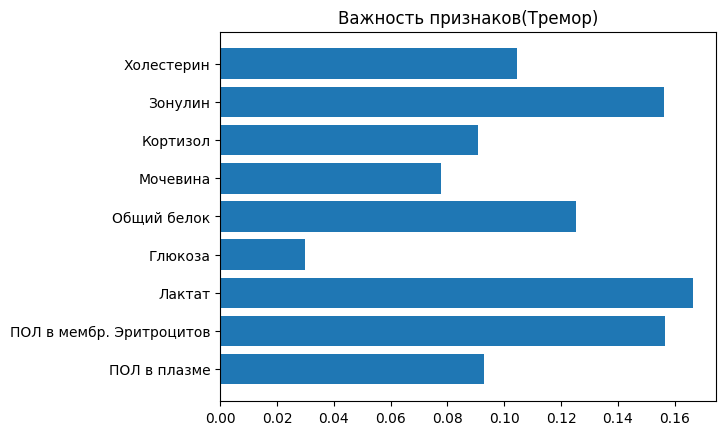

In [28]:


plt.barh(columns_name, feature_importances)
plt.title('Важность признаков(Тремор)')
plt.show()